In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.strategy import momentum_strategy
from src.backtest import backtest, results_table, optimize
from src.visualization import plot_performance


In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


## Momentum Strategy, Window = 5

## Momentum Strategy, Window = 10

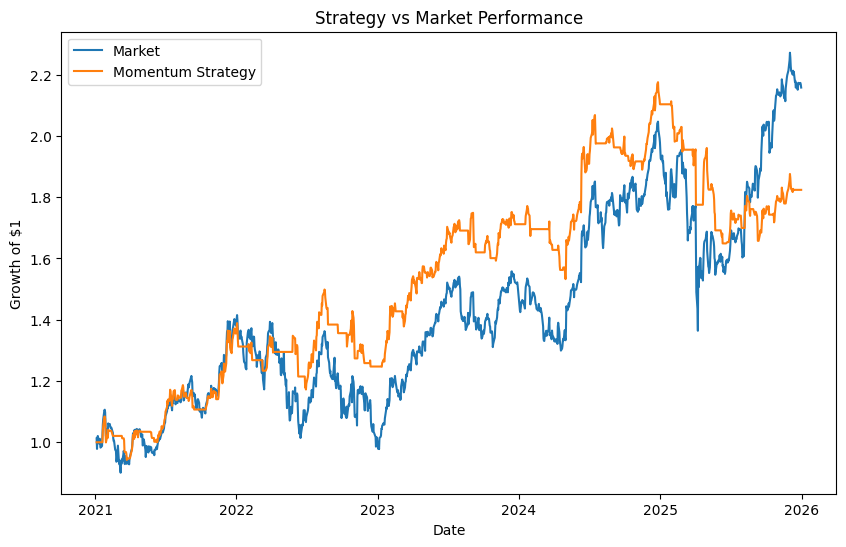

In [3]:
df = base_df.copy()
df = momentum_strategy(df)
df = backtest(df)

plot_performance(df)

In [4]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.758120,0.180887,-0.241998


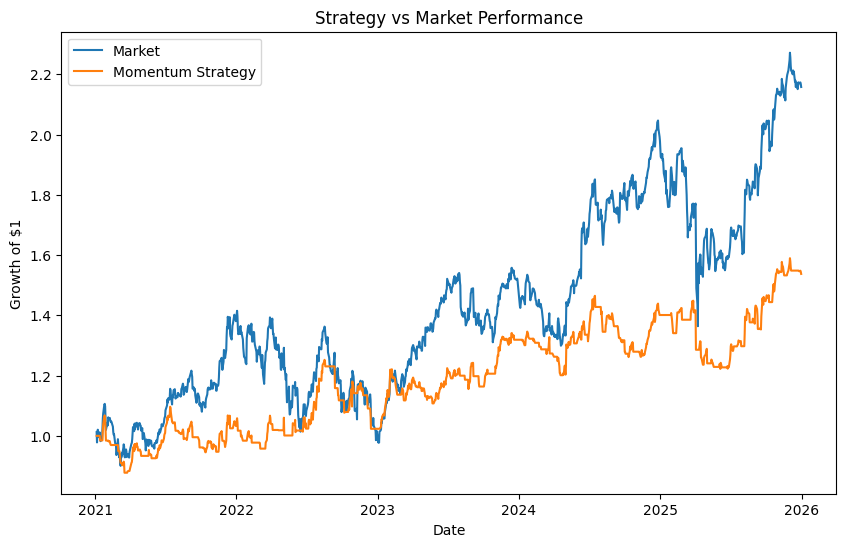

In [5]:
df = base_df.copy()
df = momentum_strategy(df, window = 5)
df = backtest(df)


plot_performance(df)

In [6]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.568911,0.180697,-0.182805


## Momentum Strategy, Window = 20

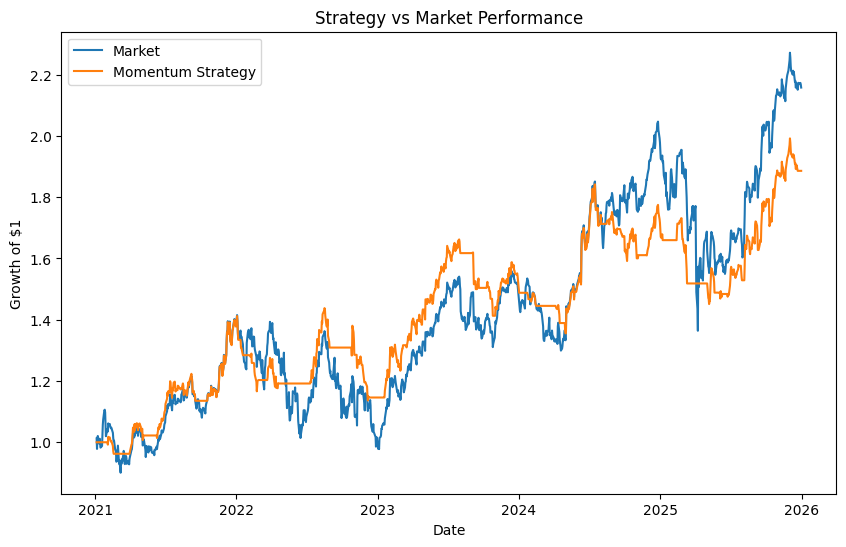

In [7]:
df = base_df.copy()
df = momentum_strategy(df, window = 20)
df = backtest(df)


plot_performance(df)

In [8]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.809951,0.176537,-0.212237


## Momentum Strategy, Window = 50

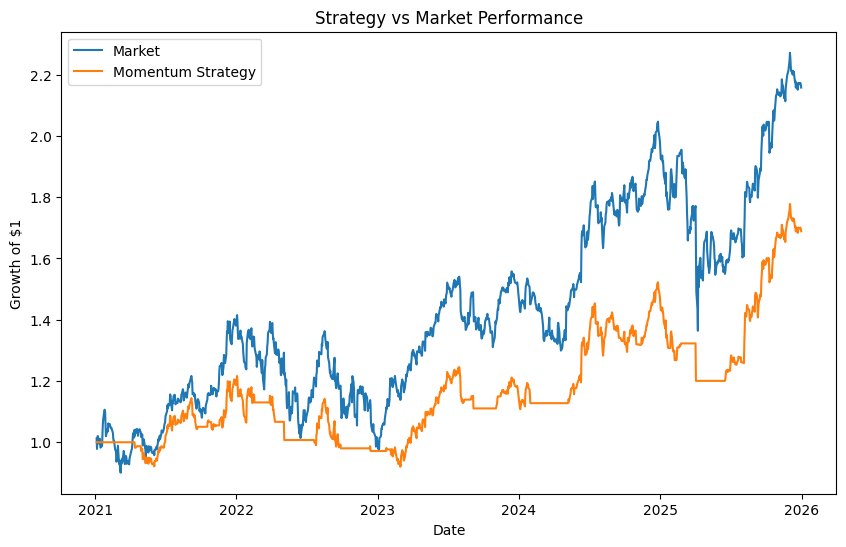

In [9]:
df = base_df.copy()
df = momentum_strategy(df, window = 50)
df = backtest(df)


plot_performance(df)

In [10]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.676844,0.179370,-0.243727


## Window Test

Momentum
Market Returns Sharpe Ratio: 0.6934951138350013
Best Momentum Strategy window: 6
Best Sharpe ratio: 0.9918


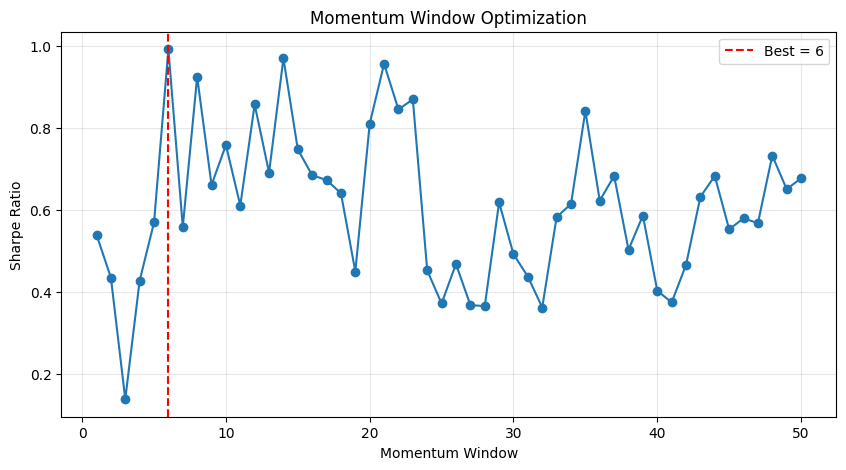

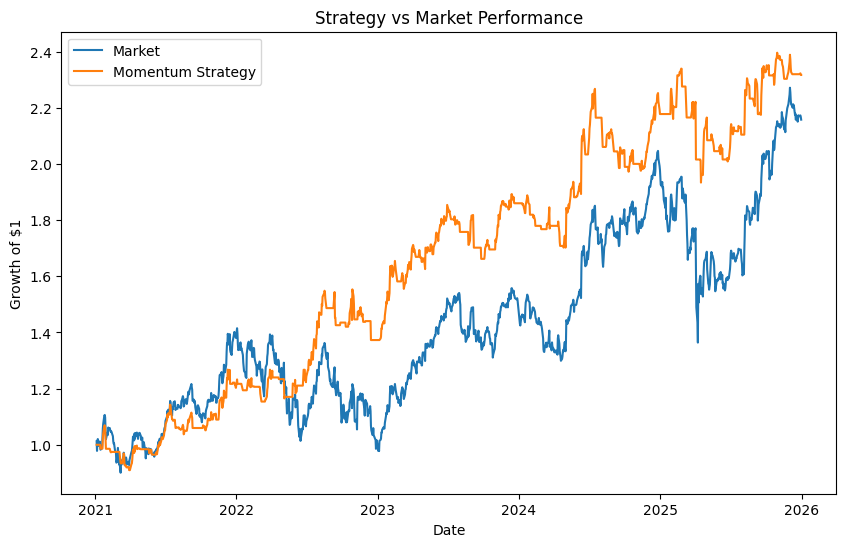

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum,0.991822,0.188117,-0.173479


In [11]:
df = base_df.copy()
strategy = [
    ('Momentum', momentum_strategy, 'mom', None)
]
window = range(1, 51)

optimize(df, strategy, window)